# Dump 1 noise-pulse survey — series 07221203_2025

**Series:** `07221203_2025` (R76, Run76 log)
**Dump:** `F0001` ("dump 1")
**Run log context** (from `R76/DataSeriesList.xlsx`, `Run76` sheet):

| field | value |
|---|---|
| type | Side2 |
| source / shield | PuBe / Pb&poly, lead stack, borax |
| HV | -83.2 V |
| trigger | DCRC1pA 2 |
| source position | Position 3 |
| duration | 30 min |
| notes | low-trigger threshold data |

This is the only R76-tagged series already present locally under `~/idx/` (the other two
local dumps, `07180808_1558_F0009` and `07180827_0000_F00xx`, are tagged `R68` in the
nsdf-cli manifest) — if you meant a different series, swap the path in the cell below.

**Goal:** set up a first pass at picking out "good" noise pulses — individual channel traces
that look like pure stationary baseline noise, with no real physics pulse riding on top —
as a starting point for a noise PSD study. There's no dedicated "Randoms" trigger in this
dump (only `Physics` and `Unknown`), so the cut below is data-driven: it compares each
trace's full-length excursion to its own pretrigger baseline scatter, rather than relying
on a trigger-type flag.

Run this notebook with the `darkmatter_cli_env` conda environment (same as
`R76Noise.ipynb` / `NSDF_noise.ipynb`) so `nsdf_dark_matter` and `openvisusnogui` are available.

In [1]:
from nsdf_dark_matter.idx import load_all_data
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

home_directory = Path.home()
series_path = str(home_directory) + '/idx/07221203_2025_F0001'
print("loading:", series_path)

cdms = load_all_data(series_path)

loading: /Users/villaa/idx/07221203_2025_F0001


In [2]:
event_ids = cdms.get_event_ids()
detector_ids = cdms.get_detector_ids()

print(f"events: {len(event_ids)}")
print(f"channel groups (detector_ids): {len(detector_ids)}")
print("sample detector id:", detector_ids[0])

sample_meta = cdms.get_event_metadata(event_ids[0])
print("sample event metadata:", sample_meta.trigger_type, sample_meta.readout_type, sample_meta.global_timestamp)

events: 1570
channel groups (detector_ids): 4551
sample detector id: 10000_0_Phonon_4096
sample event metadata: Physics None Sunday, December 04, 2022 02:25:47 AM UTC


In [3]:
from collections import Counter

trigger_counts = Counter(cdms.get_event_metadata(e).trigger_type for e in event_ids)
print("trigger type counts:", trigger_counts)

trigger type counts: Counter({'Physics': 1008, 'Unknown': 562})


## Per-trace baseline stats

Each `detector_id` (an `<event>_<group>_Phonon_4096` entry) returns 4 channel traces of
4096 ADC samples (uint16). For every individual channel trace we compute:

- `bmean`, `bstd` — mean and std of a pretrigger window (first 1000 samples)
- `dev` — the largest deviation from `bmean` anywhere in the *full* 4096-sample trace
- `ratio = dev / bstd` — how many "pretrigger sigma" the biggest excursion in the trace
  reaches. A trace that's flat noise all the way through has a small ratio; a trace with
  a real pulse (or a glitch) spikes far above its own baseline scatter.

Channels with `bstd == 0` are excluded up front — a perfectly flat pretrigger window means
the channel is dead/unread for that trace, not quiet noise.

In [4]:
PRETRIGGER_SAMPLES = 1000

records = []  # (detector_id, channel_index, bmean, bstd, dev)
for d in detector_ids:
    channels = cdms.get_detector_channels(d)
    for c in range(channels.shape[0]):
        trace = channels[c].astype(np.float64)
        base = trace[:PRETRIGGER_SAMPLES]
        bmean, bstd = base.mean(), base.std()
        dev = np.max(np.abs(trace - bmean))
        records.append((d, c, bmean, bstd, dev))

detector_id_arr = np.array([r[0] for r in records])
channel_arr = np.array([r[1] for r in records])
bmean_arr = np.array([r[2] for r in records])
bstd_arr = np.array([r[3] for r in records])
dev_arr = np.array([r[4] for r in records])

active = bstd_arr > 0
ratio_arr = np.full_like(bstd_arr, np.inf)
ratio_arr[active] = dev_arr[active] / bstd_arr[active]

print(f"total channel traces: {len(records)}")
print(f"active (nonzero pretrigger std): {active.sum()} ({100*active.sum()/len(records):.1f}%)")

total channel traces: 18204
active (nonzero pretrigger std): 10619 (58.3%)


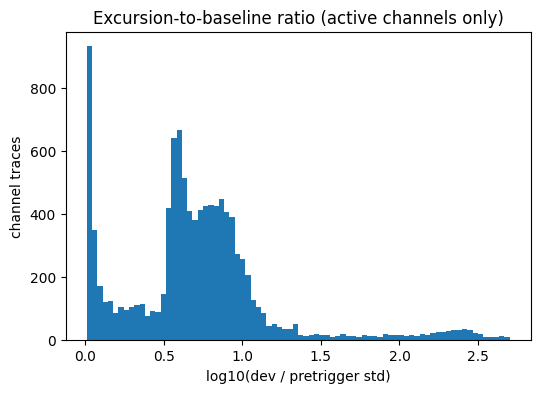

ratio percentiles (active only):
  p10: 1.13
  p25: 3.23
  p50: 4.77
  p75: 7.80
  p90: 12.56
  p95: 44.69
  p99: 279.35


In [5]:
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(np.log10(ratio_arr[active]), bins=80)
ax.set_xlabel("log10(dev / pretrigger std)")
ax.set_ylabel("channel traces")
ax.set_title("Excursion-to-baseline ratio (active channels only)")
plt.show()

print("ratio percentiles (active only):")
for p in [10, 25, 50, 75, 90, 95, 99]:
    print(f"  p{p}: {np.percentile(ratio_arr[active], p):.2f}")

## "Good noise" selection

Starting cut: **active channel** (`bstd > 0`) **and** `ratio < GOOD_RATIO_THRESH`
(no excursion in the trace exceeds `GOOD_RATIO_THRESH` times the pretrigger scatter).

`GOOD_RATIO_THRESH = 5` is a first-pass value — from the percentiles above it keeps
roughly the quietest half of active channels. Tighten it (e.g. 3) for a purer noise
sample, or loosen it (e.g. 8-10) if you need more statistics and can tolerate a few
low-amplitude pulses leaking in.

In [6]:
GOOD_RATIO_THRESH = 5

good_mask = active & (ratio_arr < GOOD_RATIO_THRESH)
n_good = good_mask.sum()

print(f"good noise traces: {n_good} / {len(records)} "
      f"({100*n_good/len(records):.1f}% of all, {100*n_good/active.sum():.1f}% of active)")

good_detector_ids = detector_id_arr[good_mask]
good_channels = channel_arr[good_mask]

good noise traces: 5544 / 18204 (30.5% of all, 52.2% of active)


## Visual check: good noise traces vs. rejected (pulse-like) traces

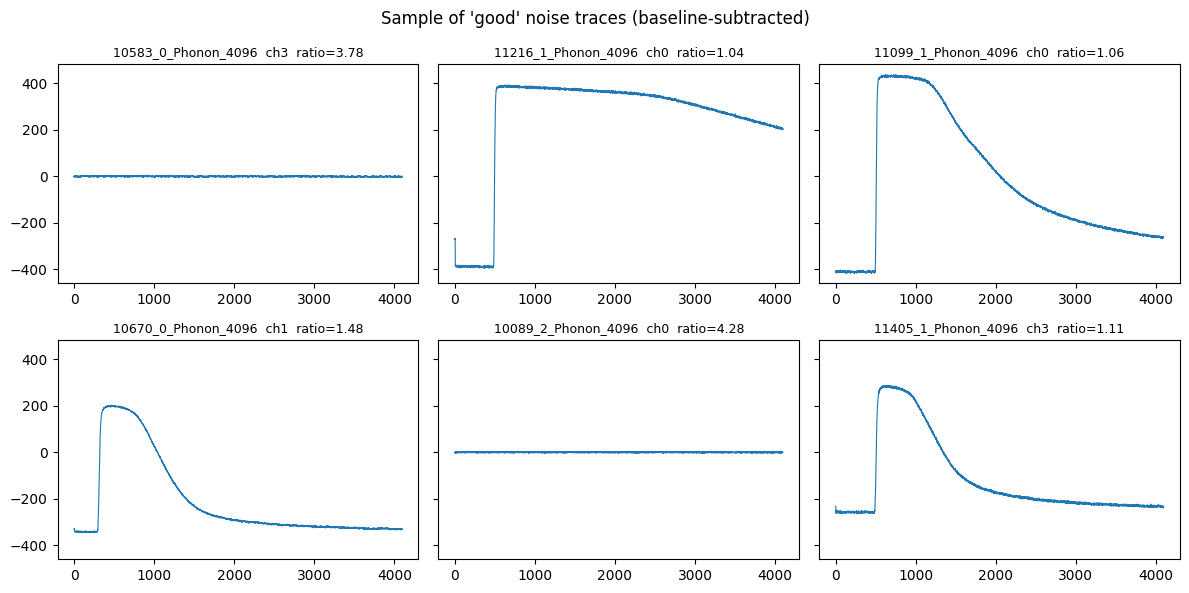

In [7]:
rng = np.random.default_rng(0)
n_show = 6

good_idx = rng.choice(np.where(good_mask)[0], size=n_show, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharey=True)
for ax, i in zip(axes.flat, good_idx):
    d, c = detector_id_arr[i], channel_arr[i]
    trace = cdms.get_detector_channels(d)[c].astype(np.float64)
    trace -= trace[:PRETRIGGER_SAMPLES].mean()
    ax.plot(trace, linewidth=0.8)
    ax.set_title(f"{d}  ch{c}  ratio={ratio_arr[i]:.2f}", fontsize=9)
fig.suptitle("Sample of 'good' noise traces (baseline-subtracted)")
fig.tight_layout()
plt.show()

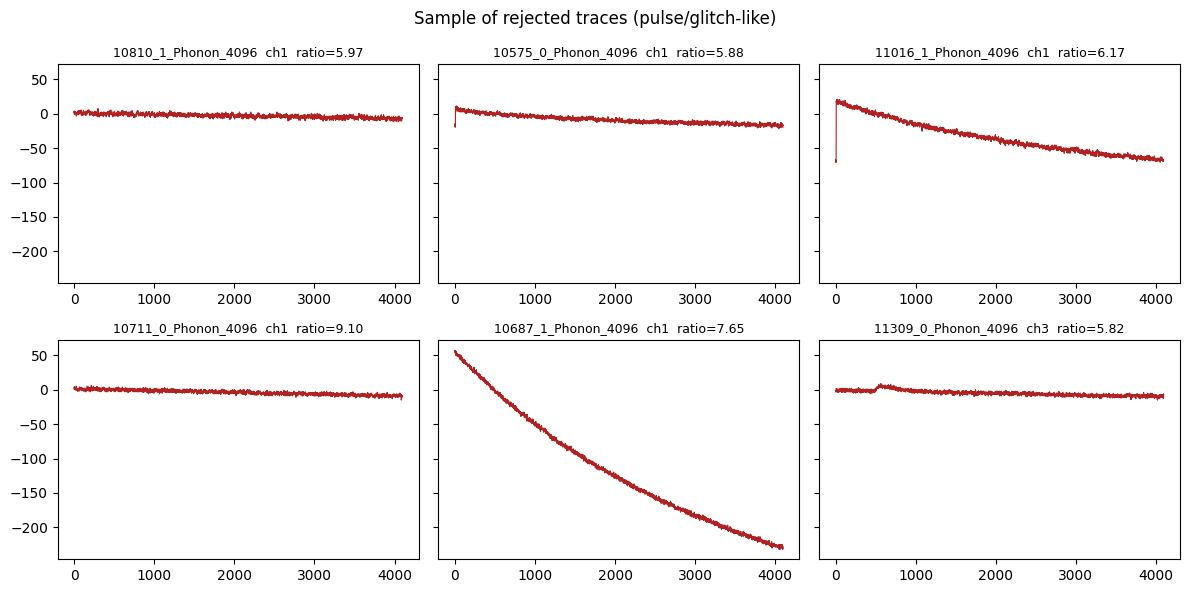

In [8]:
rejected_mask = active & (ratio_arr >= GOOD_RATIO_THRESH)
rej_idx = rng.choice(np.where(rejected_mask)[0], size=n_show, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharey=True)
for ax, i in zip(axes.flat, rej_idx):
    d, c = detector_id_arr[i], channel_arr[i]
    trace = cdms.get_detector_channels(d)[c].astype(np.float64)
    trace -= trace[:PRETRIGGER_SAMPLES].mean()
    ax.plot(trace, linewidth=0.8, color='firebrick')
    ax.set_title(f"{d}  ch{c}  ratio={ratio_arr[i]:.2f}", fontsize=9)
fig.suptitle("Sample of rejected traces (pulse/glitch-like)")
fig.tight_layout()
plt.show()

## Next steps

- Eyeball the two grids above — tune `GOOD_RATIO_THRESH` until "good" really looks flat
  and "rejected" really looks pulse-like, then re-run.
- Save `good_detector_ids` / `good_channels` (e.g. to a `.npy` or `.csv` in
  `analysis_notes/`) so downstream notebooks don't have to redo this selection.
- Once a stable "good noise" sample exists, compute an average noise PSD from it
  (`np.fft.rfft` per trace, average `|FFT|^2`) as the actual deliverable of this study.
- Cross-check flagged-bad series from the run log's `notes` column (e.g. Run76's
  `07220426_1120` was noted "noise outlier") against this trace-level cut to sanity-check
  the threshold against what the experimenters already flagged by hand.